# Importação de Bibliotecas

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D,MaxPooling2D,Flatten,Dense,Dropout,Rescaling)

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"GPU encontrada: {gpus}")
else:
    print("Nenhuma GPU encontrada. Usando CPU.")

Mounted at /content/drive
GPU encontrada: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Definição de Caminhos e Acesso ao Dataset

In [ ]:
CAMINHO = "/content/drive/MyDrive/Assistente de Inteligência Artificial - FATESG/Aula - 09/"

DIR = CAMINHO + "dataset_raiox_reduzido/"
caminhoTreino = DIR + "treino"
caminhoTeste = DIR + "teste"
caminhoProducao = DIR + "producao"

# Extração de Imagens + pré-processamento

In [ ]:
dados_treino = tf.keras.utils.image_dataset_from_directory(caminhoTreino,
                                                           image_size=(252, 252),
                                                           batch_size=32,
                                                           label_mode="binary",
                                                           shuffle=True)

dados_teste = tf.keras.utils.image_dataset_from_directory(caminhoTeste,
                                                          image_size=(252, 252),
                                                          batch_size=32,
                                                          label_mode="binary",
                                                          shuffle=False)

print("\nClasses identificadas:")
print(dados_treino.class_names)

Found 420 files belonging to 2 classes.
Found 438 files belonging to 2 classes.

Classes identificadas:
['NORMAL', 'PNEUMONIA']


# Criação de Modelos

In [ ]:
modelo252x252_14x14 = Sequential([Rescaling(1./255,input_shape=(252, 252, 3)), # dropout 0.2
                                                                  # adaptado p/252x252
Conv2D(32,(3, 3),activation="relu"), # 252 x 252
MaxPooling2D((3, 3)), # -> 126 x 126
Dropout(0.2),
Conv2D(32,(3, 3),
activation="relu"),
MaxPooling2D((3, 3)), # -> 42 x 42
Dropout(0.2),
Conv2D(64,(3, 3),
activation="relu"),
MaxPooling2D((3, 3)), # -> 14 x 14

Flatten(),

Dense(128,activation="relu"),
Dropout(0.2),
Dense(128,activation="relu"),
Dropout(0.2),
Dense(1,activation="sigmoid")
])

modelo252x252_7x7 = Sequential([Rescaling(1./255,input_shape=(252, 252, 3)), # dropout 0.2
                                                                  # adaptado p/252x252
Conv2D(64,(3, 3),activation="relu"), # 252 x 252
MaxPooling2D((3, 3)), # -> 126 x 126
Dropout(0.2),
Conv2D(64,(3, 3),
activation="relu"),
MaxPooling2D((3, 3)), # -> 42 x 42
Dropout(0.2),
Conv2D(64,(3, 3),
activation="relu"),
MaxPooling2D((3, 3)), # -> 14 x 14
Dropout(0.2),
Conv2D(128,(3, 3),
activation="relu"),
MaxPooling2D((2, 2)), # -> 7 x 7
Dropout(0.2),
Flatten(),

Dense(256,activation="relu"),
Dropout(0.2),
Dense(256,activation="relu"),
Dropout(0.2),
Dense(1,activation="sigmoid")
])

modelo252x252_14x14.summary(), modelo252x252_7x7.summary()

modelo252x252_14x14.compile(optimizer="adam",loss="binary_crossentropy",
                            metrics=["accuracy",
                                     tf.keras.metrics.Precision(name='precision'),
                                     tf.keras.metrics.Recall(name='recall'),
                                     tf.keras.metrics.F1Score(name='f1_score')]), modelo252x252_7x7.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy",
                                                                                                                                                                 tf.keras.metrics.Precision(name='precision'),
                                                                                                                                                                 tf.keras.metrics.Recall(name='recall'),
                                                                                                                                                                 tf.keras.metrics.F1Score(name='f1_score')])

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_14 (Rescaling)        │ (None, 252, 252, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 250, 250, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 83, 83, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 83, 83, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 81, 81, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 27, 27, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_71 (Dropout)            │ (None, 27, 27, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_72 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_73 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 569,697 (2.17 MB)

 Trainable params: 569,697 (2.17 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_15 (Rescaling)        │ (None, 252, 252, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 250, 250, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 83, 83, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 83, 83, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 81, 81, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_53 (MaxPooling2D) │ (None, 27, 27, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_75 (Dropout)            │ (None, 27, 27, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 25, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_76 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_77 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_78 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_79 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 510,721 (1.95 MB)

 Trainable params: 510,721 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

(None, None)

# Treino do Modelo

Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 985ms/step - accuracy: 0.5333 - f1_score: 0.6792 - loss: 0.7188 - precision: 0.5521 - recall: 0.4907 - val_accuracy: 0.4658 - val_f1_score: 0.6355 - val_loss: 0.6951 - val_precision: 0.4658 - val_recall: 1.0000
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 591ms/step - accuracy: 0.5500 - f1_score: 0.6792 - loss: 0.6922 - precision: 0.5345 - recall: 0.9676 - val_accuracy: 0.8196 - val_f1_score: 0.6355 - val_loss: 0.6899 - val_precision: 0.8492 - val_recall: 0.7451
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 494ms/step - accuracy: 0.5690 - f1_score: 0.6792 - loss: 0.6752 - precision: 0.6061 - recall: 0.4630 - val_accuracy: 0.5708 - val_f1_score: 0.6355 - val_loss: 0.6742 - val_precision: 0.5208 - val_recall: 0.9804
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 628ms/step - accuracy: 0.6714 - f1_score: 0.6792 - loss: 0.6154 - precision: 0.6625 - recall: 0.7361 - val_accuracy: 0.8037 - val_f1_score: 0.6355 - val_loss: 0.5898 - val_precision: 0.7500 - val_recal

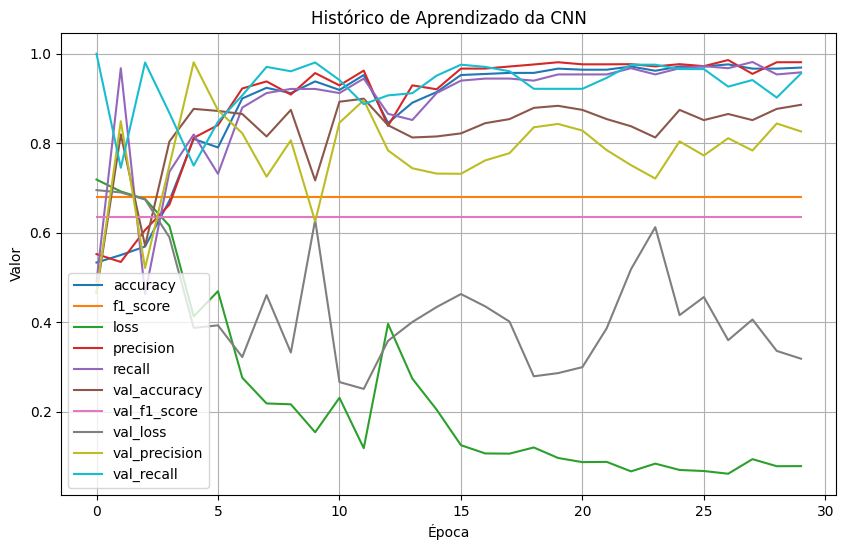

In [ ]:
historicoAprendizado = modelo252x252_14x14.fit(dados_treino,epochs=30,validation_data=dados_teste)

pd.DataFrame(historicoAprendizado.history).plot(figsize=(10, 6))

plt.grid(True)
plt.xlabel("Época")
plt.ylabel("Valor")
plt.title("Histórico de Aprendizado da CNN")
plt.show()

In [ ]:
metrics = modelo252x252_14x14.evaluate(dados_teste)

print("\nResultados:")
print(metrics)

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 247ms/step - accuracy: 0.8858 - f1_score: 0.6355 - loss: 0.3183 - precision: 0.8263 - recall: 0.9559

Resultados:
[0.31828826665878296, 0.8858447670936584, 0.8262711763381958, 0.9558823704719543, 0.635513961315155]


In [ ]:
modelo252x252_7x7.save("modelo252x252_7x7_700Mparams_30epoc92acc63f1sc87prec97rec.h5")